In [1]:
"""
v1_extraction.py
-----------------
Goal of this version (v1):
    Take one free-format MT599 SWIFT message (which may contain ONE OR MORE
    settlement instructions embedded in plain text) and extract a SINGLE
    structured JSON output containing a list of instructions.

    No branching / routing / validation-loop logic yet -- that comes in v2/v3.
    This file's only job: prove that "free text -> reliable structured JSON"
    works end-to-end using an LLM served via Together AI, wrapped by
    LangChain's with_structured_output(), inside a (currently one-node)
    LangGraph graph.

Why a LangGraph graph at all for a single LLM call?
    Because we are deliberately building this as the first node of a larger
    graph (routing, validation loop, multi-instruction map-reduce come next).
    Starting the plumbing now means v2/v3/v4 are additive, not a rewrite.
"""

import os
import json
from enum import Enum
from typing import Optional, List, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA
#    This is the contract between "whatever the LLM says" and "what our
#    downstream settlement system receives". Pydantic enforces this shape;
#    LangChain uses it to instruct/parse the LLM's structured response.
# ---------------------------------------------------------------------------

class InstructionType(str, Enum):
    """
    The ONE field we constrain to a fixed set of values, because the graph
    will branch on this field in v2 (cancel vs create vs amend routing).
    Every other field stays a free string (see design notes below), but this
    one needs to be reliable, so we force the LLM to pick from exactly these
    four values instead of letting it write "Cancellation", "CANCEL", etc.
    """
    cancel = "cancel"
    create = "create"
    amend = "amend"
    unidentified = "unidentified"  # used when no operation could be found


class Instruction(BaseModel):
    """
    One settlement instruction extracted from the message.

    Design decision: every field except `type` is a plain Optional[str].
    We deliberately do NOT try to cast qty to int or settlementDate to a
    date object here. Reasons:
      1. MT599 is free text -- dates/numbers can appear in inconsistent
         formats, and asking a small LLM to also normalize formats increases
         the chance of it silently getting the normalization wrong.
      2. The receiving settlement system already owns format validation
         against its own static/reference data -- duplicating that logic
         here would be redundant and a maintenance burden.
      3. Keeping types uniform (all str) keeps the Pydantic model, and the
         prompt asking the LLM to fill it, simple -- which matters when the
         LLM is a small instruct model, not a frontier reasoning model.
    """
    type: InstructionType = Field(
        description="The operation identified from the message text."
    )
    clientRef: Optional[str] = Field(
        default=None, description="Client reference for this instruction."
    )
    scRef: Optional[str] = Field(
        default=None, description="SC (settlement/system) reference, if present."
    )
    isin: Optional[str] = Field(
        default=None, description="ISIN of the security, if present."
    )
    qty: Optional[str] = Field(
        default=None, description="Quantity, captured exactly as written."
    )
    settlementDate: Optional[str] = Field(
        default=None, description="Settlement date, captured exactly as written."
    )
    sfkAccount: Optional[str] = Field(
        default=None, description="SFK account number, if present."
    )
    pset: Optional[str] = Field(
        default=None, description="Place of settlement, if present."
    )
    party: Optional[str] = Field(
        default=None, description="Party details, if present."
    )
    cpty: Optional[str] = Field(
        default=None, description="Counterparty details, if present."
    )
    remarks: Optional[str] = Field(
        default=None,
        description=(
            "Free-text notes. MUST explain the reason when type is "
            "'unidentified'. Otherwise null."
        ),
    )


class ExtractionResult(BaseModel):
    """
    Top-level shape returned by the extraction node.

    Design decision: ALWAYS a list, even for a single instruction, and
    ALWAYS non-empty (minimum one entry -- an 'unidentified' placeholder if
    nothing else could be found). This means downstream consumers never
    need to handle "no instructions" as a separate shape from "one
    instruction" from "many instructions" -- one contract, always.
    """
    instructions: List[Instruction] = Field(
        description=(
            "One or more instructions found in the message. If nothing "
            "could be identified, return exactly one instruction with "
            "type='unidentified' and an explanation in remarks."
        )
    )


C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP (Together AI via LangChain)
# ---------------------------------------------------------------------------

# Model choice rationale (see chat discussion):
#   - Qwen2.5-7B-Instruct-Turbo is confirmed (via LangChain's own docs) to
#     work with ChatTogether's with_structured_output().
#   - It's small/cheap/fast -- good for learning the LangGraph plumbing.
#   - Swap to "Qwen/Qwen2.5-72B-Instruct-Turbo" (one string change) once you
#     want to stress-test with messier / longer MT599 text.
TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,  # deterministic extraction -- we want repeatable JSON, not creative text
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

# method="json_schema" asks the model to emit JSON conforming to our Pydantic
# schema, and LangChain parses + validates it back into an ExtractionResult.
# This is more robust for smaller instruct models than relying purely on
# native tool/function-calling, which some smaller models handle less
# reliably.
structured_llm = llm.with_structured_output(ExtractionResult, method="json_schema")
 

In [7]:
# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

EXTRACTION_PROMPT = """You are parsing a free-format MT599 SWIFT message used in trade settlement.

The message may contain ONE OR MORE distinct instructions (cancellation, creation, amendment),
mixed together in free text, in any order.

For EACH instruction you find, extract:
- type: cancel, create, amend, or unidentified
- clientRef, scRef, isin, qty, settlementDate, sfkAccount, pset, party, cpty
- remarks: only used to explain when type is "unidentified"

Rules:
1. Capture every field exactly as written in the message. Do NOT reformat dates,
   numbers, or reference codes.
2. If a field is not mentioned for an instruction, leave it null. Do not guess.
3. If you cannot identify ANY operation in the entire message, return exactly ONE
   instruction with type="unidentified" and a short explanation in remarks.
4. Return every instruction you find -- do not drop or merge separate instructions.

Message:
\"\"\"{message}\"\"\"
"""


In [9]:
# ---------------------------------------------------------------------------
# 4. GRAPH STATE
# ---------------------------------------------------------------------------

class SettlementState(TypedDict):
    raw_message: str                       # input: the MT599 free text
    result: Optional[ExtractionResult]      # output: structured extraction
    error: Optional[str]                    # populated only if extraction ultimately fails


# ---------------------------------------------------------------------------
# 5. NODE: extract_instructions
#    Includes a one-shot repair retry -- if the model's first attempt fails
#    Pydantic validation (malformed JSON, wrong enum value, etc.), we retry
#    once with the validation error fed back into the prompt. This is a
#    small but real production safeguard, especially relevant for smaller
#    instruct models which are more prone to malformed structured output
#    than larger ones.
# ---------------------------------------------------------------------------

MAX_ATTEMPTS = 2


def extract_instructions(state: SettlementState) -> SettlementState:
    message = state["raw_message"]
    last_error: Optional[str] = None

    for attempt in range(1, MAX_ATTEMPTS + 1):
        prompt = EXTRACTION_PROMPT.format(message=message)

        # On a retry, tell the model what went wrong last time.
        if last_error:
            prompt += (
                f"\n\nYour previous response was invalid: {last_error}\n"
                "Please correct it and return valid JSON matching the schema."
            )

        try:
            result = structured_llm.invoke(prompt)
            state["result"] = result
            state["error"] = None
            return state
        except ValidationError as ve:
            last_error = str(ve)
        except Exception as e:
            # Covers cases like malformed JSON that never reaches Pydantic
            # validation (e.g. the model wrapped JSON in prose).
            last_error = str(e)

    # All attempts exhausted -- fail loudly rather than silently, and still
    # return the SAME shape the rest of the graph expects, with a fallback
    # 'unidentified' instruction so downstream code never has to special-case
    # a total failure differently from a partial one.
    state["result"] = ExtractionResult(
        instructions=[
            Instruction(
                type=InstructionType.unidentified,
                remarks=f"Extraction failed after {MAX_ATTEMPTS} attempts: {last_error}",
            )
        ]
    )
    state["error"] = last_error
    return state


In [11]:
# ---------------------------------------------------------------------------
# 6. BUILD THE GRAPH
#    Only one node for now -- v2 adds conditional routing after this node,
#    v3 adds a validation loop, v4 adds multi-instruction map-reduce.
# ---------------------------------------------------------------------------

builder = StateGraph(SettlementState)
builder.add_node("extract_instructions", extract_instructions)
builder.set_entry_point("extract_instructions")
builder.set_finish_point("extract_instructions")

graph = builder.compile()


In [15]:

# ---------------------------------------------------------------------------
# 6b. VISUALIZE THE GRAPH
#     Same idea as the draw_mermaid_png() calls in your earlier lemon-juice
#     notebooks, but made to work whether this file is run as a plain
#     script or inside a Jupyter notebook:
#       - Inside Jupyter/IPython -> render inline (like your notebooks did).
#       - As a plain .py script   -> save a PNG file to disk instead, since
#         there's no notebook cell to render into.
#     v1 only has one node, so the diagram will look trivial -- it becomes
#     genuinely useful from v2 onward once routing/loops are added, so it's
#     worth having this wired up now rather than bolting it on later.
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        # If we're inside Jupyter/IPython, render inline -- same behaviour
        # as your existing notebooks.
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass  # IPython not installed -- fall through to saving the file

    # Plain script (or IPython not available) -- save to disk instead.
    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")


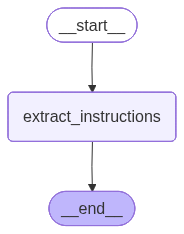

{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": "1234",
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    }
  ]
}


In [17]:
# ---------------------------------------------------------------------------
# 7. QUICK TEST
# ---------------------------------------------------------------------------


if __name__ == "__main__":
    # Show the graph structure before running it -- trivial for v1 (one
    # node), but keep this call in place; it's where you'll actually see
    # the branching/looping shape appear once v2/v3 add to the graph.
    visualize_graph(graph)

    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100, SFK Account = 1234"
    )

    final_state = graph.invoke({
        "raw_message": sample_message,
        "result": None,
        "error": None,
    })

    # .model_dump() converts the Pydantic object back to a plain dict/JSON
    print(json.dumps(final_state["result"].model_dump(), indent=2))